In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
fake = pd.read_csv('../demos/Fake.csv')
true = pd.read_csv('../demos/True.csv')

# Add labels
fake['label'] = 0  # 0 = Fake
true['label'] = 1  # 1 = Real

# Combine
df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())
print(df.head())

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 

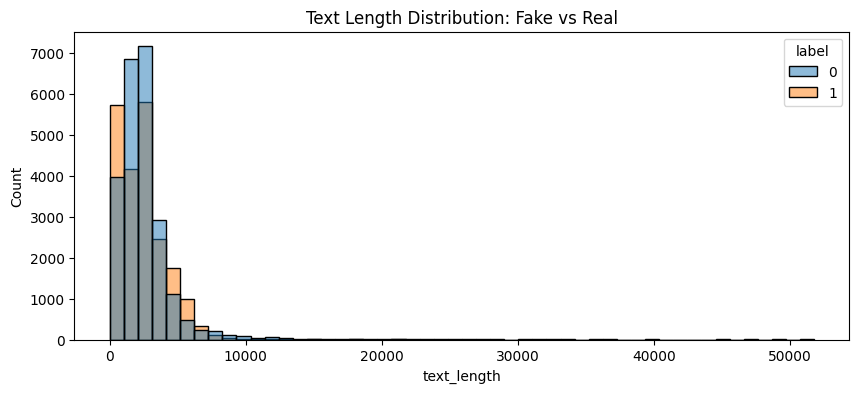

label
0    0.522985
1    0.477015
Name: proportion, dtype: float64


In [2]:
import os

# Text length distribution
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10,4))
sns.histplot(data=df, x='text_length', hue='label', bins=50)
plt.title('Text Length Distribution: Fake vs Real')
os.makedirs('../model', exist_ok=True)
plt.savefig('../model/eda_plot.png')
plt.show()

# Class balance check
print(df['label'].value_counts(normalize=True))